# `bw_timex` Teaching Example - Time-explicit LCA of an Electric Vehicle

Here's a rundown of the steps involved in a `TimexLCA`:

<div style="display: flex; justify-content: center; background-color: white; border-radius: 15px; padding: 10px; width: 600px; margin: auto;">
  <img src="../data/workflow.svg" style="border-radius: 15px; width: 100%;">
</div>


## **Step 0**: Initial Setup _(normal brightway stuff)_


Restore backed-up project with some prepared databases (only do this _once_):


In [1]:
import bw2data as bd

bd.projects.set_current("ei312_REMIND_EU")

In [2]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]  # to make sure we create the foreground from scratch
foreground = bd.Database("foreground")
foreground.register()

```mermaid
flowchart LR
    car_prod_wo_battery(market for passenger car, electric, without battery, GLO):::ei-->ev_production
    battery_production(market for battery, Li-ion, LiMn2O4, rechargeable, prismatic, GLO):::ei-->ev_production
    ev_production(ev production):::fg-->driving
    electricity_generation(market group for electricity, low voltage, GLO):::ei-->driving
    driving(driving ev):::fg-->battery_eol(market for used Li-ion battery, GLO):::ei
    driving-->fu(FU: driving 100,000 km)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


Legend:

```mermaid
flowchart TB
    background(background process):::ei
    foreground(foreground process):::fg

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


### Creating foreground processes


In [3]:
ev_production = foreground.new_node(
    "ev_production", name="production of an electric vehicle", unit="unit"
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

driving = foreground.new_node(
    "driving", name="driving an electric vehicle", unit="pkm over ev lifetime"
)
driving["reference product"] = "person transport"
driving.save()

### Adding exchanges


In [4]:
ELECTRICITY_CONSUMPTION = 0.2  # kWh/km
LIFETIME_KM = 100_000  # km
MASS_CAR_WITHOUT_BATTERY = 840  # kg
MASS_BATTERY = 280  # kg

BG_DATABASE = "ei312_REMIND-EU_SSP2_NDC_2020"

In [5]:
car_without_battery = bd.get_node(
    database=BG_DATABASE,
    name="market for passenger car, electric, without battery",
)
battery = bd.get_node(
    database=BG_DATABASE,
    name="market for battery, Li-ion, LiMn2O4, rechargeable",
)
electricity = bd.get_node(
    database=BG_DATABASE,
    name="market group for electricity, low voltage",
    location="GLO",
)
battery_eol = bd.get_node(
    database=BG_DATABASE,
    name="market for used Li-ion battery",
)

In [6]:
ev_production.new_edge(input=ev_production, amount=1, type="production").save()

car_without_battery_to_ev = ev_production.new_edge(
    input=car_without_battery, amount=MASS_CAR_WITHOUT_BATTERY, type="technosphere"
)
car_without_battery_to_ev.save()

battery_to_ev = ev_production.new_edge(
    input=battery, amount=MASS_BATTERY, type="technosphere"
)
battery_to_ev.save()

In [7]:
driving.new_edge(input=driving, amount=1, type="production").save()

ev_to_driving = driving.new_edge(input=ev_production, amount=1, type="technosphere")
ev_to_driving.save()

electricity_to_driving = driving.new_edge(
    input=electricity,
    amount=ELECTRICITY_CONSUMPTION * LIFETIME_KM,
    type="technosphere",
)
electricity_to_driving.save()

driving_to_battery_eol = driving.new_edge(
    input=battery_eol,
    amount=-MASS_BATTERY,  # used battery is "produced"
    type="technosphere",
)
driving_to_battery_eol.save()

With this setup, we could now run a normal, static LCA:


In [8]:
import bw2calc as bc

method = (
    "ecoinvent-3.12",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)
lca = bc.LCA({driving: 1}, method)
lca.lci()
lca.lcia()
lca.score

/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.13/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.90e+13)
  warnings.warn(msg, UmfpackWarning)


21882.062546933954

Lateron, we'll want to use prospective background databases. We create those using [premise](https://premise.readthedocs.io/en/latest/). Here, we use a very optimistic decarbonization scenario (REMIND-EU PkBudg650 -> ~1.5-1.9°C warming by 2100).

To enable mapping between the databases, we save the info which database represent what point in time in a dictionary:


In [9]:
from datetime import datetime

database_dates = {
    "ei312_REMIND-EU_SSP2_NDC_2020": datetime.strptime("2020", "%Y"),
    "ei312_REMIND-EU_SSP2_NDC_2030": datetime.strptime("2030", "%Y"),
    "ei312_REMIND-EU_SSP2_NDC_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",  # Doesn't have a fixed date, but will be distributed over time
}

## **Step 1**: Adding temporal information


```mermaid
flowchart LR
    car_prod_wo_battery(🚗 market for passenger car, electric, without battery, GLO):::ei-->|1-2 years prior|ev_production
    battery_production(🔋 market for battery, Li-ion, LiMn2O4, rechargeable, prismatic, GLO):::ei-->|6-9 months prior|ev_production
    ev_production(🔌🚗 ev production):::fg-->|1-3 months prior|driving
    electricity_generation(⚡ market group for electricity, low voltage, GLO):::ei-->|uniformly distributed over lifetime|driving
    driving(🛣️ driving ev):::fg-->|3 months after lifetime|battery_eol(🗑️🔋 market for used Li-ion battery, GLO):::ei
    driving-->fu(**FU**: driving 100,000 km, *uniformly over lifetime, starting 2025*)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


### The `TemporalDistribution` class


In [10]:
from bw_temporalis import TemporalDistribution
import numpy as np

td_car_without_battery_production = TemporalDistribution(
    date=np.array([-2, -1], dtype="timedelta64[Y]"),  # yearly resolution
    amount=np.array([0.2, 0.8]),
)

td_assembly_and_delivery = TemporalDistribution(
    date=np.array([-3, -2, -1], dtype="timedelta64[M]"),  # monthly resolution
    amount=np.array([0.3, 0.5, 0.2]),
)

#### How TDs cascade through the supply chain?


<Axes: xlabel='Time (Months)', ylabel='Amount'>

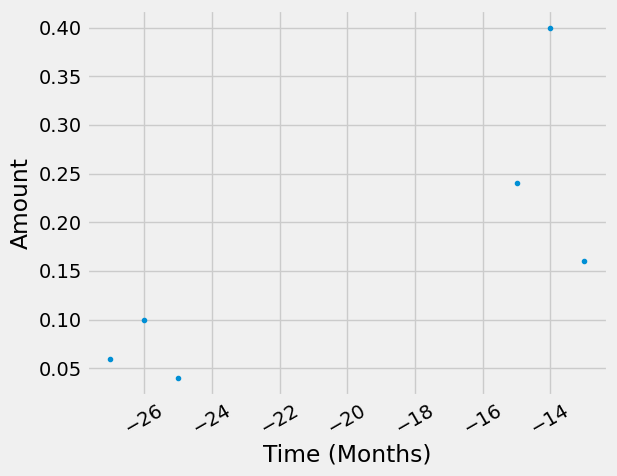

In [11]:
convolved_td = td_car_without_battery_production * td_assembly_and_delivery
convolved_td.graph(resolution="M")

#### Creating the remaining TDs


In [12]:
from bw_temporalis import easy_timedelta_distribution

td_battery_production = easy_timedelta_distribution(
    start=-9,
    end=-6,
    resolution="M",
    steps=4,
    kind="normal",  # you can also use "uniform" or "triangular"
    param=0.5,
)

LIFETIME = 15  # years
td_electricity_consumption = easy_timedelta_distribution(
    start=0,
    end=LIFETIME,
    resolution="Y",
    steps=(LIFETIME + 1),
    kind="uniform",
)

td_battery_eol = TemporalDistribution(
    date=np.array([LIFETIME * 12 + 3], dtype="timedelta64[M]"), amount=np.array([1])
)

#### Adding TDs to the exchanges


In [13]:
car_without_battery_to_ev["temporal_distribution"] = td_car_without_battery_production
car_without_battery_to_ev.save()

battery_to_ev["temporal_distribution"] = td_battery_production
battery_to_ev.save()

ev_to_driving["temporal_distribution"] = td_assembly_and_delivery
ev_to_driving.save()

# if you dont have the exchange object at hand, you can also use our util function:
from bw_timex.utils import add_temporal_distribution_to_exchange

add_temporal_distribution_to_exchange(
    td_electricity_consumption,
    input_node=electricity,
    output_node=driving,
)

add_temporal_distribution_to_exchange(
    td_battery_eol,
    input_node=battery_eol,
    output_node=driving,
)

2026-06-11 10:38:12.064 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:500 - Added temporal distribution to exchange Exchange: 20000.0 kilowatt hour 'market group for electricity, low voltage' (kilowatt hour, GLO, None) to 'driving an electric vehicle' (pkm over ev lifetime, GLO, None).
2026-06-11 10:38:12.068 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:500 - Added temporal distribution to exchange Exchange: -280 kilogram 'market for used Li-ion battery' (kilogram, GLO, None) to 'driving an electric vehicle' (pkm over ev lifetime, GLO, None).


### Specify prospective background database dates

Created with [`premise`](https://github.com/polca/premise) following the REMIND-EU SSP2 NDC scenario.


In [14]:
from datetime import datetime

database_dates = {
    "ei312_REMIND-EU_SSP2_NDC_2020": datetime.strptime("2020", "%Y"),
    "ei312_REMIND-EU_SSP2_NDC_2030": datetime.strptime("2030", "%Y"),
    "ei312_REMIND-EU_SSP2_NDC_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",  # Doesn't have a fixed date, but will be distributed over time
}

## **Step 2**: Building the process timeline


In [16]:
from bw_timex import TimexLCA

tlca = TimexLCA({driving: 1}, method, database_dates)

2026-06-11 10:38:22.687 | INFO     | bw_timex.timex_lca:__init__:136 - Initializing TimexLCA object...
2026-06-11 10:38:22.688 | INFO     | bw_timex.timex_lca:__init__:153 - Calculating base LCA...
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.13/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.65e+13)
  warnings.warn(msg, UmfpackWarning)
2026-06-11 10:38:25.052 | INFO     | bw_timex.timex_lca:__init__:170 - Collecting node infos...


In [17]:
tlca.build_timeline(
    starting_datetime="2025-01-01", temporal_grouping="month", graph_traversal="bfs"
)

2026-06-11 10:38:33.468 | INFO     | bw_timex.timex_lca:build_timeline:301 - No edge filter function provided. Skipping all edges in background databases.
2026-06-11 10:38:37.733 | INFO     | bw_timex.timex_lca:build_timeline:319 - Creating activity time mapping...
2026-06-11 10:38:37.852 | INFO     | bw_timex.timeline_builder:__init__:103 - Traversing supply chain graph...
2026-06-11 10:38:37.913 | INFO     | bw_timex.timeline_builder:build_timeline:159 - Building timeline...
2026-06-11 10:38:37.935 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:583 - Reference date 2040-04-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2022-10-01,"market for passenger car, electric, without ba...",2024-10-01,production of an electric vehicle,168.0,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.725, 'ei31..."
1,2022-11-01,"market for passenger car, electric, without ba...",2024-11-01,production of an electric vehicle,168.0,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.717, 'ei31..."
2,2022-12-01,"market for passenger car, electric, without ba...",2024-12-01,production of an electric vehicle,168.0,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.708, 'ei31..."
3,2023-10-01,"market for passenger car, electric, without ba...",2024-10-01,production of an electric vehicle,672.0,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.625, 'ei31..."
4,2023-11-01,"market for passenger car, electric, without ba...",2024-11-01,production of an electric vehicle,672.0,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.617, 'ei31..."
5,2023-12-01,"market for passenger car, electric, without ba...",2024-12-01,production of an electric vehicle,672.0,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.609, 'ei31..."
6,2024-01-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-10-01,production of an electric vehicle,54.695544,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.6, 'ei312_..."
7,2024-02-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-10-01,production of an electric vehicle,85.304456,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.592, 'ei31..."
8,2024-02-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-11-01,production of an electric vehicle,54.695544,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.592, 'ei31..."
9,2024-03-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-10-01,production of an electric vehicle,85.304456,"{'ei312_REMIND-EU_SSP2_NDC_2020': 0.584, 'ei31..."


## **Step 3**: Calculating the time-explicit LCI


In [18]:
tlca.lci()

2026-06-11 10:38:42.297 | INFO     | bw_timex.timex_lca:lci:453 - Expanding matrices...
2026-06-11 10:38:42.317 | INFO     | bw_timex.timex_lca:lci:472 - Calculating dynamic inventory...
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.13/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 4.97e+12)
  warnings.warn(msg, UmfpackWarning)
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.13/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 4.97e+12)
  warnings.warn(msg, UmfpackWarning)


Under the hood, before solving the inventory problem, we're re-build the technosphere and biosphere matrices here. New rows and columns are added to carry the extra temporal information. Details are explained in the [Theory Section](https://docs.brightway.dev/projects/bw-timex/en/latest/content/theory.html#modifying-the-matrices) of our docs.


## **Step 4**: Impact assessment


The simplest case, static LCIA:


In [19]:
tlca.static_lcia()
tlca.static_score

13372.0761526528

But there is more: `bw_timex` retains temporal information in the inventory, allowing for dynamic LCIA:


In [20]:
tlca.dynamic_lcia(metric="GWP")

2026-06-11 10:39:05.659 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


,date,amount,flow,activity
0,2023-01-01,-0.002927,267655083766312992,323380307438338050
1,2023-01-01,-0.001756,267655083766312992,323380307438338049
2,2023-01-01,-0.001171,267655083766312992,323380307438338051
3,2023-01-01,-0.000198,267655084332544077,323380307438338050
4,2023-01-01,-0.000119,267655084332544077,323380307438338049
...,...,...,...,...
2373,2040-01-01,1.457417,267655084441596001,323380307438338080
2374,2040-01-01,1.838855,267655084861026358,323380307438338080
2375,2040-01-01,4.953395,267655084978466867,323380307438338080
2376,2040-01-01,7.004325,267655084978466867,323380307438338081


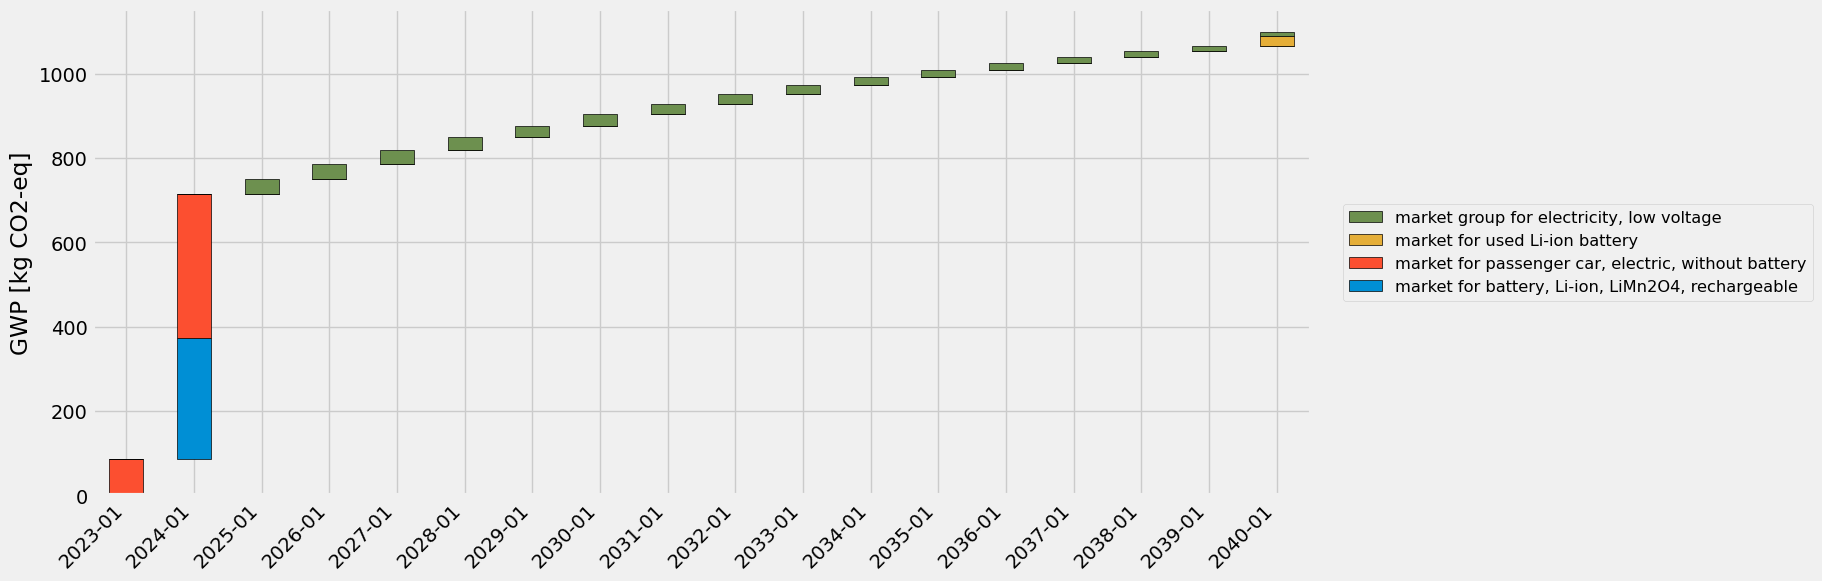

In [21]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

plot_characterized_inventory_as_waterfall(tlca)

In addition to the "standard" GWP, we can go even more dynamic, directly assessing radiative forcing:


In [22]:
tlca.dynamic_lcia(
    metric="radiative_forcing",
    time_horizon=30,
)

2026-06-11 10:39:07.872 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


,date,amount,flow,activity
0,2024-01-01 05:49:12,-4.820865e-18,267655083766312992,323380307438338050
1,2024-01-01 05:49:12,-2.892507e-18,267655083766312992,323380307438338049
2,2024-01-01 05:49:12,-1.928355e-18,267655083766312992,323380307438338051
3,2024-01-01 05:49:12,-3.258956e-19,267655084332544077,323380307438338050
4,2024-01-01 05:49:12,-1.955427e-19,267655084332544077,323380307438338049
...,...,...,...,...
54105,2068-12-31 00:46:48,9.778114e-16,267655084441596001,323380307438338080
54106,2068-12-31 00:46:48,1.679234e-15,267655084861026358,323380307438338080
54107,2068-12-31 00:46:48,3.323335e-15,267655084978466867,323380307438338080
54108,2068-12-31 00:46:48,4.699347e-15,267655084978466867,323380307438338081


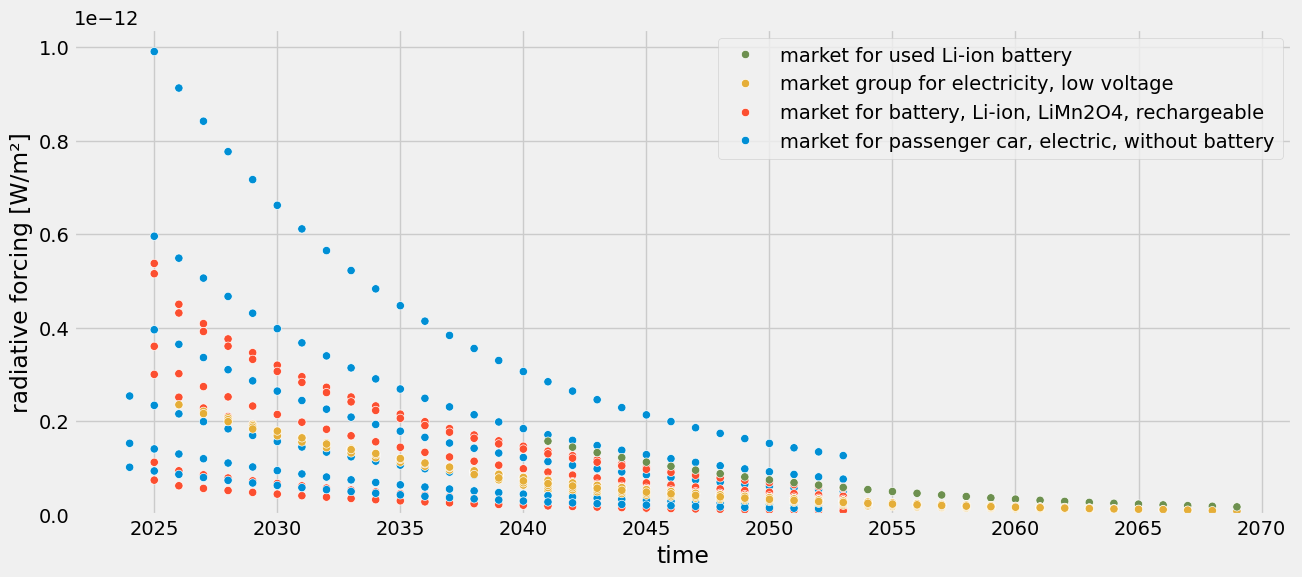

In [23]:
tlca.plot_dynamic_characterized_inventory(
    sum_emissions_within_activity=True,
)

## Quick Recap
This might have seemed quite lengthy now. But essentially, calculating a `TimexLCA` is just this:

In [ ]:
tlca = TimexLCA(demand={driving: 1}, method=method, database_dates=database_dates)
tlca.build_timeline(starting_datetime="2025-01-01", temporal_grouping="month", graph_traversal="bfs")
tlca.lci()
tlca.static_lcia()
tlca.static_score

2026-06-11 10:39:10.168 | INFO     | bw_timex.timex_lca:__init__:136 - Initializing TimexLCA object...
2026-06-11 10:39:10.169 | INFO     | bw_timex.timex_lca:__init__:153 - Calculating base LCA...
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.13/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.65e+13)
  warnings.warn(msg, UmfpackWarning)
2026-06-11 10:39:12.718 | INFO     | bw_timex.timex_lca:__init__:170 - Collecting node infos...
2026-06-11 10:39:23.825 | INFO     | bw_timex.timex_lca:build_timeline:301 - No edge filter function provided. Skipping all edges in background databases.
2026-06-11 10:39:28.259 | INFO     | bw_timex.timex_lca:build_timeline:319 - Creating activity time mapping...
2026-06-11 10:39:28.387 | INFO     | bw_timex.timeline_builder:__init__:103 - Traversing supply chain graph...
2026-06-11 10:39:28.458 | INFO     | bw_timex.timeline_builder:build_timeline:159 - Building timeline..

13372.0761526528